# Key Methods in Physical Geography
# Computing Practical 4: Sequential Data Analysis

This is a Jupyter notebook running on the University of Edinburgh Noteable Service (https://www.ed.ac.uk/information-services/learning-technology/noteable/intro). Notebooks are interactive documents that can contain computer code (Python for this course), text and images.

For some components in this notebook, data files will be used. Any data file that is used for plotting with this and other notebooks needs to be uploaded to the Jupyter server -- unless they are provided for you, or there are commands provided to download the files directly to the Jupyter practical folder.

### Key Learning Outcomes

This practical deals with analysis of data that depends on time or some other univariate data -- essentially, data you can plot in a line curve. Concepts introduced earlier will be explored further. Along the way we will learn how to analyse a new data format and how to write user-defined functions, and develop our coding skills further.

- Using python without Noteable

- Reading data from climate files

- User-defined functions

- Linear Regression

- Slicing and For Loops, revisited

- Grouping time series by Day/Month/Year

- Creating Pandas dataframes from arrays


## Using python without Noteable

Noteable is a powerful tool to use, but it is something differen than python itself. It provides us these neat web pages in the form of notebooks, but behind the scenes the *python interpreter* is taking in the commands we enter -- Noteable is just a nice way to interface with it.

However, at some point in your later courses, or your dissertation, or your Masters, or your job, you likely will need to use python without the support of Noteable. This may be the case if you need to work on a data file that is too large for Noteable, or you may need to install specialist software and do not have permission to do so with Noteable. 

It would be irresponsible of us to let you think that all python code must be run in Noteable or even in a notebook.

Here you are going to run python code which does tasks similar to what you programmed in the last practical, but without a notebook. It will also be your first exposure to linux (probably). If you are a mac user, this may be helpful as using python on a mac involves using the linux terminal.

### A linux terminal.

Go back to the directory page in noteable where you see a list of files. Select "new" in the top right, but do not create a new notebook! Select **terminal**. 

![capture](Capture.png)

You will then be taken to a new tab, with a mostly black screen with white characters -- do you see it? This is how people used to use a computer before interactive windows and point-and-click was developed. Some still do, because it gives them more control. 

![capture](Capture2.PNG)

### Changing the "current directory."

The only way you can do commands here are via text at the command line; you cannot move the cursor with your mouse. Type `ls` and hit enter. You will be given a list of all subdirectories (i of course have more than you):

```
jovyan@jupyter-3ph2ysz2r7zep5d4wypjpm-747dfb684-tnblk:~$ ls
 chubda                    GEGR090182021-2SS1SEM1   MODIS_aqua_notebooks      
 cold_bay_8_mhhw_2013.nc   gradebook.db             mouginot_files              
 course_notebooks          horsing_around           ndow_diss                
 EASC101032019-0SS1YR      IcelandDataFolder        peru_glacier_smb_folder
 GEGR090182020-1SS1SEM1    lost+found               release
 ```
 
There you see the folder for your course, `GEGR090182023-4SS1SEM1`. You cannot click on it! To "enter" it you must type

```
cd GEGR090182023-4SS1SEM1
```

after the `$` symbol. When you type `ls` and enter again, you should see the names of the practicals for this course. (If not, ask me or a demonstrator for help.) To enter this week's practical folder, type

``` 
cd Practical_4
```

Your current directory should now be our practical folder. To verify type `ls` again to make sure you see a list of the files for this practical. 

### Running a Python script from the command line.

The place where you are typing commands is often called the "command line". In linux, we can use this to call programs, such as python. Type at the command line, 

```
python por_histogram.py
```

and hit enter. `por_histogram.py` is pure python code without a notebook. (Have a look at it!) It does the same thing you did at the start of last week -- read a text file of porosities, and create a histogram. Almost immediately you should see the message, `program run, figure saved!`. If not, talk to a demonstrator. But if it worked, you should see a new file (`histogram.png`) in your folder (you may need to browser-refresh). 

This is how you can use python without Noteable. It might seem nonintuitive, but it is actually a nice way to do things if you cannot use a notebook for the reasons given above -- and if you ever need to do it, at least you will have done it before.

## Reading data from climate files

An emphasis of this course is in how to make sense of the myriad file formats one needs to deal with when analysing geographical and geoscientific data. Until now we have encountered text files, `.csv` files (essentially text files) and shape files. Shape files are a form of *vector* data, where data is described only at the locations needed; this is in contrast with *raster* data which is described on a uniform, or semi-uniform, *grid*. Next week we will encounter **geotiff** files, which is a common format for raster data used in GIS applications.

geotiff files, however, are unsuitable formats for a wide range of data types -- such as climate data, which is often stored on three-dimensional grids with multiple time levels. It is often difficult, or impossible, to visualise or process such data in programs like QGIS. This can sometimes be an issue for dissertation research; even if climate data analysis is not the main aim of the dissertation, it might need to be examined or looked at. From my experience, **a huge annoyance of geography BSc dissertations is downloading large climate data files, only to find out they cannot be opened in a GIS application**. 

For this reason, in this practical you will be introduced to a common data format used in climate modelling and analysis -- **netCDF**. The name actually is short for "network Common Data Format". The data we will use for this practical is simply a time series, and thus could be provided in a text file; but it has been transferred into netCDF format as a gentle introduction to the process.

As with shapefiles, we will need to load a specialised python library to read netCDF files. A (relatively) easy one to use is `xarray`. The cell below imports this library with `xr` as a shorthand name -- be sure to run it.

In [1]:
import xarray as xr

We will now use xarray to open a netCDF file. You will hopefully see that while the specific commands differ from those used with pandas and geopandas, the overall pattern is similar: a function is called to open the file, returning a variable; the variable is used to extract arrays and other information. **Do not worry that you might not remember the specific commands -- the important thing is to have a reference, such as these worked notebooks, to refer to.**

In your practical folder there is a file called `HadCRUT4-gl-ann.nc`. This file is generated by the Met Office Hadley Centre and the Climatic Research Unit at the University of East Anglia
(http://www.cru.uea.ac.uk/). It contains global averages of annual anomalies in land-surface air
temperatures and sea-surface water temperatures relative to a 1961-1990 reference period. It is a netCDF file (which we know from the file extension `*.nc`). 

We will use the function `open_dataset`, which is called as:
```python
ds = xr.open_dataset(filename)
```
where `filename` is the name of the file we want to open. Recall that the square brackets are not used -- these are to indicate the *role* of the argument, not the name -- and just as with geopandas and pandas, **the filename must be in quotes**, as it is a string. In the cell below, open the Hadley/CRU file into a variable named `ds`.

In [2]:
ds = xr.open_dataset('HadCRUT4-gl-ann.nc')

As with pandas and geopandas we can see an overview of the data before extracting it. Type `ds` in the cell below and run it. What are the data variables? Click on the symbols to the right of the variable names (one looks like a stack of discs, the other like a page with its corner folded). This will allow you to see the attributes of each variable (the *metadata*) and the values. What are the units of `t_anom`? How many years are included in the data set?

In [3]:
ds

<xarray.Dataset>
Dimensions:  (time: 166)
Dimensions without coordinates: time
Data variables:
    year     (time) float64 ...
    t_anom   (time) float64 ...

We can also extract the data in the netCDF file into arrays. This is done similarly to pandas. For instance, for the `year` variable, this is done as:
```python
year = ds.year
```
However, this does not return a `numpy` array, which we are used to working with, but a variable of the type `core.dataarray.DataArray`. For most purposes (i.e. plotting) we can treat this variable as if it were a `numpy` array but for some operations this might get us into trouble, so we are better off using 
```python
year = ds.year.values
```

In the following cell, extract the "year" data into an array `year` and the "t_anom" data into an array `anom`. Import `matplotlib.pyplot` and create a simple line plot of anomaly against year. Try extracting the data using both of the methods above and verify you can create the plot with each method. 

In [4]:
year = ds.year.values

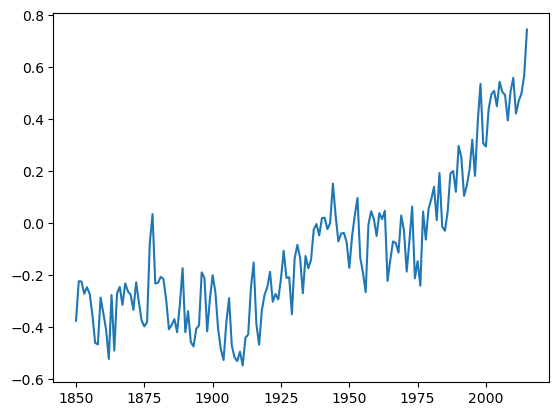

In [9]:
# extract year and anom data

year = ds.year.values
t_anom = ds.t_anom.values

# import matplotlib.pyplot and create plot
import matplotlib.pyplot as plt
plt.plot(year,t_anom)


When does warming seem to begin? One thing you may notice is that temperature did not increase at a steady rate and in fact there were different periods with very different rates of temperature change. Below you will generate robust code to show this.

## User-defined functions

What do you do if you can’t find a Python function to do what you want to do? Well, you can write a new one. User-defined functions are very useful if you have to repeat a task with different parameters, and they can make programs much neater. They are also useful if you have a number of processing steps that depend on one (or a handful of) changing value, such as a file name, and do not want to type this over and over again. As we will see next week it is a faff to retrieve georeferencing data from geotiff files. User-defined functions can be useful for opening and geo-referencing many different geotiffs.


The **syntax** (ask a demonstrator if you are unsure what this word means) for defining a function with name function, arguments args and optional returns list `rets` is
```python
def function(args):
  """
  docstring for documentation
  """
  # indented code block
  return rets
```
As with all python constructs, all subsequent lines under `def function(args):` are indented. The actual code goes between the documentation and the return. 

The operations below require moving averages of time series. NumPy does not contain a moving-average function, so we must define one. Below is code defining the function called `moving_average`. Copy it into the following cell and run it.

```python
# need to import any modules used in the function
import numpy as np

def moving_average(y, m):
 """
 2m+1 point moving average of array y.
 """
 N = y.size # find the size of y
 mm = np.zeros(N) # make an array of zeros with the same size
 # ms = np.zeros(N) # you will need this later to find a moving standard deviation
 for k in range(N): # loop for the moving average
  kmin = max(k-m, 0) # limit to indices within the array
  kmax = min(k+m, N-1) # limit to indices within the array
  mm[k] = np.mean(y[kmin:kmax])
 # later on, you will do a similar command to find ms[k], the standard deviation
 return mm
```

In [18]:
import numpy as np

def moving_average(y, m=50):
 """
 2m+1 point moving average of array y.
 """
 N = y.size # find the size of y
 mm = np.zeros(N) # make an array of zeros with the same size
 for k in range(N): # loop for the moving average
  kmin = max(k-m, 0) # limit to indices within the array
  kmax = min(k+m, N-1) # limit to indices within the array
  mm[k] = np.mean(y[kmin:kmax])
 return mm

The documentation string describes what the function does. Its first argument `y` is the time series, and `m` is the window of the average (or rather `2m+1` is the window). Contained within the function is a `for` loop with which you have some experience. Basically, the function loops over each index of the time series and calculates the local average. Finally, it returns the result. For instance,
```python
y_mavg = moving_average(y,5)
```
would return `y_mavg`, a $(2\times 5+1)=11$ point moving average of `y`.

The cell must be run in order to call the function, and any module used by the function (`numpy`) must be imported before it is run. Once running this cell, type `help(moving_average)` in the cell below to verify that you see the documentation message. Then produce an 11-point moving average of `anom` and plot this 'smoothed' anomaly as well as the original anomaly against year in the same figure.

Experiment with different averaging windows. This is somewhat subjective, and depends on prior knowledge of short-term climate fluctuation, but too short a period will not give a smooth line and too long a period will suppress any trends. E.g. what happens to the moving average if you set `m` to 50?

Do not delete the cell with this user-defined function, we will come back to it (and modify it)!

Help on function moving_average in module __main__:

moving_average(y, m=50)
    2m+1 point moving average of array y.



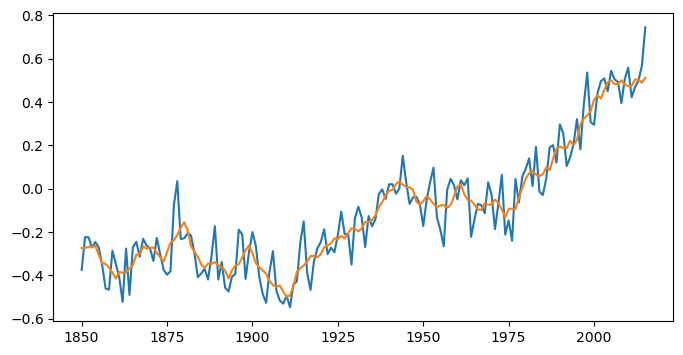

In [25]:
# import matplotlib.pyplot
import matplotlib.pyplot as plt

# view documentation
help(moving_average)

# calculate a new array as an 11-point moving average of anom
anom_avg= moving_average(t_anom,m=3)

# create figure and axes
fig, ax = plt.subplots(figsize=(8,4))

# plot anom and its moving average in the same figure
plt.plot(year,t_anom);
plt.plot(year,anom_avg);

As originally specified, `moving_average` must always be called with an argument specifying the window width (`m`). It would be nice to be able to leave this argument off if we wish to use some "default" value. This involves setting `m` as an *optional* or *keyword* argument (*kwarg* for short). For a general function this is done with the syntax
```python
def function(args, kwarg=default):
```
where `args` is the list of arguments that *must* be passed (in this case, `y`) while `kwarg` denotes a keyword argument which if not passed is set to the value `default`. 

Redefine `moving_average` so that `m` is a keyword argument with default 5, and re-run the cell defining it.

## Linear regression

The function `scipy.stats.linregress` calculates a regression line for data points in two array arguments. The regression line is the "best fit" line to the data (for more detail read "correlation.pdf" under Data Analysis Notes on Learn). The function returns five variables: the slope (m) and intercept (c) of the line, the correlation coefficient and its p-value (which we found last week with `pearsonr`), and the **standard error of the estimate** (the average distance of data points from the regression line). Five named variables are required to catch all of these numbers, e.g.
```python
m, c, r, p, se = linregress(x, y)
```
(x must be the independent variable.) If you only want some of the variables (say m and c), you can use an underscore as a throwaway variable:
```python
m, c, _, _, _ = linregress(x, y)
```
In the cell below, find a best-fit trendline for global temperature anomaly and print the results. (You will first need to import `linregress` from `scipy.stats`.)

In [27]:
# import appropriate function
from scipy.stats import linregress

# find regression variables
m, c, _, _, _ = linregress(year, t_anom)


How good is the fit? We could consider the standard error of the estimate, but it is more instructive to plot the regression line and data together. In the cell below, generate an array for the best-fit line. Do this using the formula

$$
 anom_{fit} = m \times (year) + c
$$

where $m$ is regression slope and $c$ is the intercept. You can do this easily with the variables of `c` and `m` you found with `linregress` and the array `year`. Define a new array (e.g. `anom_fit`) using this formula, and plot it along with the (non-averaged) anomaly. Is this trend significant? Moreover, is it representative of the temperature trends in the industrial era?

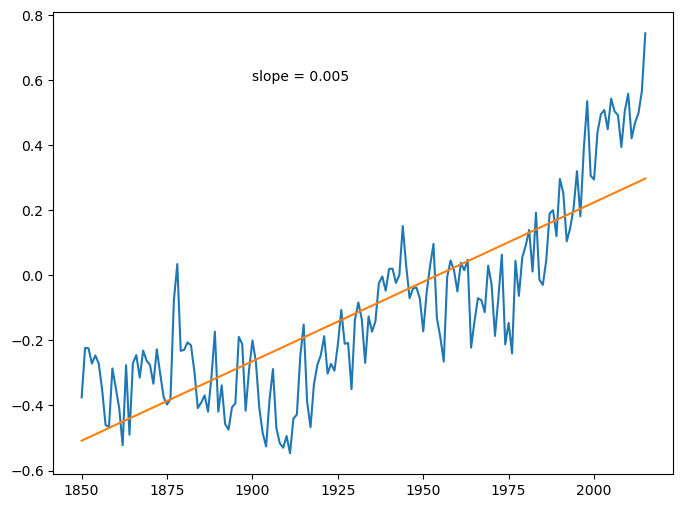

In [33]:
# define new array containing regression line values
anom_fit = m * year + c

# create figure and axes
fig, ax = plt.subplots(figsize=(8,6))

# plot anom and its best fit line in the same figure
plt.plot(year, t_anom)
plt.plot(year,anom_fit)


# plot the slope in a text label (see below)
plt.text(1900,0.6,'slope = ' + str(np.round(m,3)));



We have not done so before but `matplotlib` allows us to place text labels on a figure at specified coordinates:
```python
plt.text(x_position,y_position,text)
```
where the `text` argument must be a string. Modify the previous cell to place a text box indicating the slope (something like "slope = ___". The easiest way to do this is to print the variable `c` and type the value in a string, but a more robust way to do this is to generate a string using the `str` function, as when you printed descriptive statistics in last week's tutorial. (In fact, below we will generate multiple best fit lines with labels, and it will be tedious to type each value.)

## Slicing, revisited

It is clear from the plot of temperature anomaly there have been different trends during different time periods. Here, let's analyse the period from 1910 to 1939. 1910 corresponds to row **60** of the anomaly dataset i.e. `year[60]=1910`. In the following cell redo the linear regression analysis and plot of the regression line, but this time base the regression on years 1910 to 1939 **only** (and limit the plot of the best fit line to these years as well). 

To do this you will need to generate a new array containing only the years 1910 to 1940 and a new array containing the corresponding anomaly values. The easiest way to do this is by taking a slice from 60:90 of both arrays.

If the best-fit line is difficult to see, you can try modifying the width with the `linewidth` kwarg.

ValueError: x and y must have same first dimension, but have shapes (166,) and (2, 166)

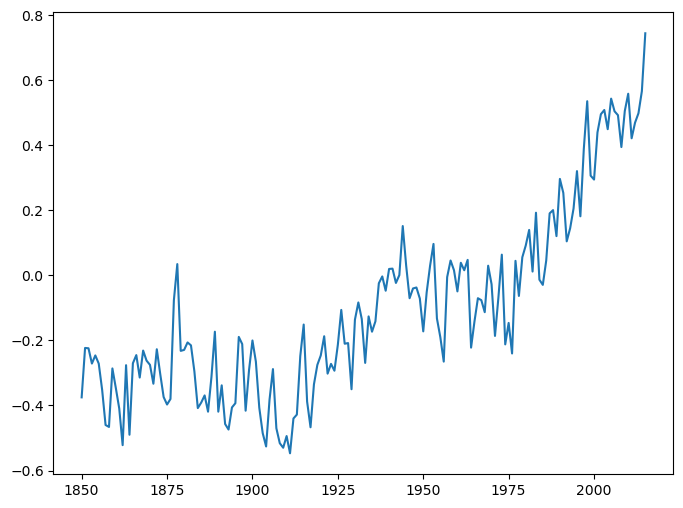

In [57]:
# create figure and axes
fig, ax = plt.subplots(figsize=(8,6))

# re-calculate moving average (you will see why)
anom_avg = moving_average(t_anom)

# plot anom and its moving average (full range) 
plt.plot(year,t_anom)
plt.plot(year,anom_avg)

# generate arrays which are subsets of year and anom, via slicing
year1850 = year[0:30]
t_anom1850 = t_anom[0:30]

# redo linear regression using these smaller arrays
m, c, _, _, _ = linregress(year1850, t_anom1850)

# define new array containing regression line values, limited to the new date range (1910-1940)
anom_fit1850 = m * year1850 + c

# plot best-fit line (subset range) on figure
plt.plot(year1910,anom_fit1910,linewidth=5)

# plot the slope in an appropriate position
plt.text(1925,.5,'Slope = ' + str(np.round(m,5)))


## For Loops, revisited

The previous exercise did not do anything fundamentally new, but you might notice that the regression trend is more representative over this period, and it would be interesting to see if this is true over all 30-year sub-periods. 

If this above code is written well, then simply replacing the range `60:90` by, say, `0:30` and re-running would result in a best-fit line for the period 1850 to 1879. (try it!) We could copy and paste the code 5 times, modifying in the appropriate place each time, but this would not be a great way to do this (for reasons given below). A better way is to use a **for-loop** -- remember them?

We can create a for loop which steps a loop variable `y0` from 0 (corresponding to 1850) to 150
(corresponding to 1970) in steps of 30 years. Copy the code from the above cell into the one below -- and then *modify* such that all the code specific to sub-periods is within such a for-loop (remember to indent). The slicing range will no longer be `60:90`, or `0:30`, but the slicing bounds will now depend on the loop variable as `y0:y0+30`. 

You might wish to have a consistent color for each 30-year best-fit curve, and you will need to modify the code so that the position of the text box changes each time. If you have done this correct, the plot will look very professional (label the axes to make it more so).

in this iteration of the for-loop, y0 is equal to: 0
in this iteration of the for-loop, y0 is equal to: 30
in this iteration of the for-loop, y0 is equal to: 60
in this iteration of the for-loop, y0 is equal to: 90
in this iteration of the for-loop, y0 is equal to: 120


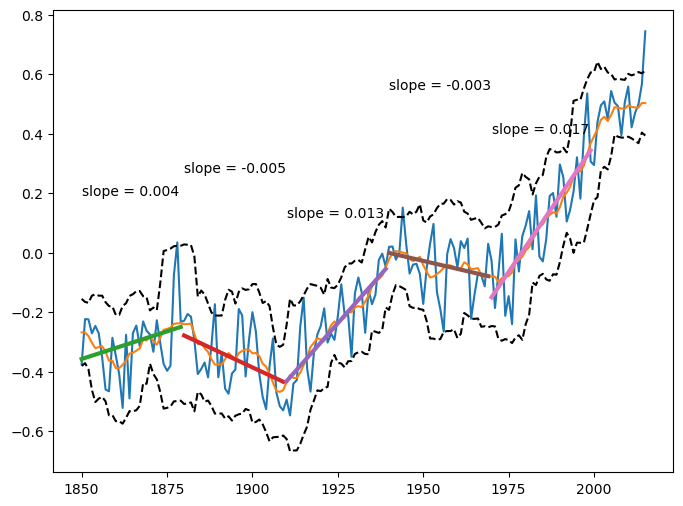

In [54]:
# this will be the start of your loop. All code to be repeated must be indented
for y0 in range(0,150,30):
    
    # this is a simple command to show how y0 is changing, you can remove it if you like. You need to add lines of code below
    print('in this iteration of the for-loop, y0 is equal to: ' + str(y0))
    
# monstration, the moving_average function is defined, but modified per instructions below. 
# This is because it now returns a list of arrays (a "tuple"), and 
# defining it this way would cause some code prior to this point not to run.

import numpy as np

def moving_average(y, m=5):
 """
 2m+1 point moving average of array y.
 """
 N = y.size # find the size of y
 mm = np.zeros(N) # make an array of zeros with the same size
 ms = np.zeros(N)
 for k in range(N): # loop for the moving average
  kmin = max(k-m, 0) # limit to indices within the array
  kmax = min(k+m, N-1) # limit to indices within the array
  mm[k] = np.mean(y[kmin:kmax])
  ms[k] = np.std(y[kmin:kmax])
 return mm, ms

# create figure and axes
fig, ax = plt.subplots(figsize=(8,6))

# re-calculate moving average (you will see why)
anom_avg, anom_std = moving_average(t_anom)


# plot anom and its moving average (full range) 
plt.plot(year,t_anom)
plt.plot(year,anom_avg)
plt.plot(year,anom_avg-2*anom_std,'k--')
plt.plot(year,anom_avg+2*anom_std,'k--')



for y0 in [0,30,60,90,120]:
 # generate arrays which are subsets of year and anom
 yearsub = year[y0:y0+30]
 t_anomsub = t_anom[y0:y0+30]

 # redo linear regression
 m, c, _, _, _ = linregress(yearsub, t_anomsub)

 # define new array containing regression line values, limited to new subset range
 anom_fitsub = m * yearsub + c

 # plot best-fit line (subset range) on figure\
 plt.plot(yearsub,anom_fitsub,linewidth=3)


 # plot the slope in an appropriate position
 plt.text(1850+y0,anom_fitsub[0]+.55,'slope = ' + str(np.round(m,3)))

## Accounting for uncertainty (challenging!)

In addition to trends in average temperature, it might be interesting to know if the variability in temperature is changing. Go back and modify the moving average function so that it also returns a moving standard deviation. In doing this, you will need to define a new array (call it `ms`) along with `mm`. Where `mm` is set to a local mean, `ms` should be set to a local **standard deviation** using `np.std`. Finally, instead of returning `mm` you will return a **list** of variables: `mm, ms`. (Don't forget to re-run the cell where it is defined). With the right averaging window, the moving standard deviation is a *measure of uncertainty*.

Once done, modify the above cell with the for-loop over 30-year periods. Modify the call to `moving average` to return a list: `anom_av, anom_std`. You might want to run the cell again at this point: if you made an error in redefining the user-defined function, it will not "surface" until now. You will now call the function as follows:

```python
y_mavg, y_mstd = moving_average(y,5)
```
and then `y_mstd` should be the standard deviation of the `2m+1` points.

Once this runs error-free, add 2 more line-plots to the figure: `anom_av + 2*anom_std` and `anom_av - 2*anom_std`. (Use the `plot` function to make them black dashed lines to avoid confusion with other curves.) This gives the 99% **confidence interval** for the temperature anomaly, provided `anom_std` is an accurate measure of uncertainty.

## Grouping Time Series Data by Day/Month/Year

In some cases, you might be given hourly, or daily data, but your analysis will require grouping or *aggregation* by months, or years. E.g. you might need to turn a daily time series into a series of monthly means. There are ways to develop your own algorithms to do this, but this can sometimes require a high level of competence. Fortunately, the `pandas` library provides a way to do this more easily.

In your folder you have been provided an excel file from practical 2, the daily flow rate of the Water of Leith from 2014 (`WoL_2014_flow.csv`). We are going to use pandas to generate a series of monthly mean flow rate.

You have seen before how to open this file as a pandas dataframe (look back at Practical 2 if you have forgotten). In the following cell, import `pandas` as `pd` (to help with later instructions) and open this excel file using `read_csv` into a dataframe `df`.


In [58]:
import pandas as pd
df = pd.read_csv('WoL_2014_flow.csv')
df

,Date,Flowrate
0,01/01/2014,6.291
1,02/01/2014,4.906
2,03/01/2014,6.550
3,04/01/2014,4.570
4,05/01/2014,4.133
...,...,...
360,27/12/2014,2.505
361,28/12/2014,2.307
362,29/12/2014,2.077
363,30/12/2014,2.022


Remember that the dataframe has 2 columns: "Date" and "Flowrate". However, we cannot use pandas to find monthly means right away, before the "Date" column is not actually understood by pandas as containing dates -- even though they look like dates to us. Pandas thinks they are just strings. To see this, in the following cell enter 
`print(type(df.Date[0]))` in the cell below. This is the *datatype* of the first entry of the Date column. What does it say? What does `str` mean??

To change the data type to actual *dates* that pandas understands, we may need to know about the date format. View the dataframe as you did in Practical 2. How are the date strings organised? i.e. *DD/MM/YYYY* or *MM/DD/YYYY*, or something completely different??

In [59]:
print(type(df.Date[0]))

<class 'str'>


This concept of a "date" not being a "date" might seem confusing, but you may have seen it before in other contexts, for instance Excel. If you have a date within a cell (e.g. 01/01/2001) you can use the "Format" function to change what is displayed in the cell, e.g. "01-Jan-2001". However, this is only possible because Excel understands the contents of the cell as a calendar date, not just a collection of characters. We need to get pandas to recognise this data as actual dates.

We can use the pandas function `to_datetime` to convert a data column from a `string` format to a `Datetime` format. This function takes in a dataframe column (e.g. df.Date) and returns a new column which stores the data as actual dates. 

By setting a column (e.g. df.Date) to the *output* or *return* of this function, we can effectively *update* the column:

```python
df.column = pd.to_datetime(df.column, dayfirst=True)
```

Note when you do this you will replace the word "`column`" with something else (what??). Additionally, `to_datetime` has a keyword argument (kwarg) called `dayfirst`, which is by default `False`. You will have seen that the dates in the .csv file list day, then month -- meaning you must explicitly use `dayfirst=True` in the call.

In the cell below, convert the `Date` column of your dataframe to datetime. View the first entry by doing `print(df.Date[0])`. It should not be a string anymore, but rather a "timestamp". This is a new datatype allowing us to sort by and aggregate by day, month, or year (or even hour and second).

In [64]:
df.Date = pd.to_datetime(df.Date,dayfirst=True)
df.Date[0]

Timestamp('2014-01-01 00:00:00')

We are now ready to use the `groupby` function. We reference it using the dataframe i.e. `df.groupby`. The return is a **new** pandas dataframe containing aggregated information, and takes as an argument the column by which we are aggregating. So, to find the **annual sum** of flow, we would write
```python
df2 = df.groupby(df.Date.dt.year).sum()
```
Instead, in the following cell, set `df2` to the **monthly mean**. After doing this, view the resulting df2 as you viewed dataframes previously.

There are other options for aggregation to use instead of `mean()`, such as sum (`sum()`), or max (`max()`), or min (`min()`), or standard deviation (`std()`). 

In [65]:
df2 = df.groupby(df.Date.dt.month).sum()
df2

/tmp/ipykernel_87/971581813.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df2 = df.groupby(df.Date.dt.month).sum()


,Flowrate
Date,
1,94.543
2,89.382
3,64.782
4,40.881
5,30.583
6,41.090
7,13.966
8,21.463
9,14.264


You will see that there are only 12 entries in the dataframe now. However, there is actually no more Date column! (You can see this by typing `df2.Date` -- you will get an error.)

This might be an issue, if for instance you wish to make a plot of monthly (or annual) data, or otherwise analyse it somehow. This can be recovered however, as long as you retain the original data frame. For instance, the command

```python
np.unique(df.Date.dt.day)
```

will return a list of all unique day values (1 to 31) and 

```python
np.unique(df.Date.dt.year)
```

will return a list of all unique years (2014).

## Creating a Pandas Dataframe from Arrays

This `groupby` function of pandas dataframes is so useful, that it is of use to be able to create a pandas dataframe from other data formats. For instance, you might be given a time series in the form of a netCDF file, but wish to group by date. The following steps give guidelines on how to do this.

We will again read data from `WoL_2014_flow.csv` but let's pretend we can't simply use `pd.read_csv()` as before. We will use the `np.loadtxt` function -- as we want to begin with numpy arrays. You used this last week, but as a reminder: to read the flow data into an array, type below:

```python
flowArray = np.loadtxt('WoL_2014_flow.csv', skiprows=1, delimiter=',', usecols=1)
```

you'll see a *new* keyword argument (kwarg) was used here: `usecols`. This tells python that we only want to use the **second** column (but as python counts from zero, `usecols=1` means 2nd column). 

Immediately below this read the 1st column into an array called `dateArray`: 

```python
dateArray = np.loadtxt('WoL_2014_flow.csv', skiprows=1, delimiter=',', usecols=0, dtype=np.str)
```

Note that we have read only column zero, and used the kwarg, `dtype=np.str`. As with the pandas date column, check the `type` of the 1st entry of `dateArray` to confirm it is a string. 

The reason we couldn't read the whole file into a 2-column array is that numpy arrays cannot be of mixed type. One column is numbers, the other text.

In [66]:
flowArray = np.loadtxt('WoL_2014_flow.csv', skiprows=1, delimiter=',', usecols=1)
dateArray = np.loadtxt('WoL_2014_flow.csv', skiprows=1, delimiter=',', usecols=0,dtype=np.str_)

We now have 2 columns: `dateArray` and `flowArray`. We can combine these in a pandas dataframe using the function `pd.Dataframe`, which has the syntax:
```python
df = pd.DataFrame({'column1':array1, 'column2':array2, 'column3':array3, ... })
```
The argument to `Dataframe` is something called a *python Dictionary* -- which is different than dictionaries we are used to, but is just a way to organise data. It always is within curly brackets, and contains a list of pairs of column names and values. The `...` indicates the list can be as long as we like -- but in this case we have only 2 columns. With sensible names for columns and the arrays created above, see if you can use the Dataframe function to recreate the pandas dataframe containing the date and flow data that you used above, with approrpriate column names. As long as there are not syntax errors... how can you test if you are successful? 

Once you've created the dataframe, you are then at the starting point of the `group-by` exercise. So, if you have time-series data stored in arrays and you want to create monthly or yearly averages, you now have a way to do so.

In [67]:
df = pd.DataFrame({'Date':dateArray,'Flowrate':flowArray})

In [68]:
df

,Date,Flowrate
0,01/01/2014,6.291
1,02/01/2014,4.906
2,03/01/2014,6.550
3,04/01/2014,4.570
4,05/01/2014,4.133
...,...,...
360,27/12/2014,2.505
361,28/12/2014,2.307
362,29/12/2014,2.077
363,30/12/2014,2.022
